In [1]:
!pip install nilearn nibabel pandas scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
dataset = datasets.fetch_development_fmri(n_subjects=30)

phenotypic = dataset.phenotypic.copy()
ages = phenotypic["Age"].values

print("Subjects:", len(dataset.func))
print("Ages shape:", ages.shape)

[fetch_development_fmri] Added README.md to /root/nilearn_data

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri

[fetch_development_fmri] Added README.md to /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...

...

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff38da743a900176080a2/ ...

[fetch_development_fmri] Downloaded 425984 of 6384587 bytes (6.7%%,   14.1s remaining)

[fetch_development_fmri] Downloaded 3973120 of 6384587 bytes (62.2%%,    1.2s remaining)

[fetch_development_fmri]  ...done. (5 seconds, 0 min)

Subjects: 30
Ages shape: (30,)


In [4]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford] Downloaded 729088 of 25716861 bytes (2.8%%,   36.2s remaining)

[fetch_atlas_harvard_oxford] Downloaded 13385728 of 25716861 bytes (52.1%%,    1.9s remaining)

[fetch_atlas_harvard_oxford]  ...done. (3 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

In [5]:
correlation_measure = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

X = []
valid_ages = []

for func_file, age in zip(dataset.func, ages):
    try:
        time_series = masker.fit_transform(func_file)
        conn = correlation_measure.fit_transform([time_series])[0]

        upper_tri = conn[np.triu_indices_from(conn, k=1)]
        X.append(upper_tri)
        valid_ages.append(age)

    except Exception as e:
        print("Skipped:", func_file)
        print(e)

X = np.array(X)
y = np.array(valid_ages)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (30, 1128)
Target shape: (30,)


In [6]:
model = Ridge(alpha=1.0)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(model, X, y, cv=cv)

In [7]:
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
corr = np.corrcoef(y, y_pred)[0, 1]

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")
print(f"r   : {corr:.2f}")

MAE : 7.01
RMSE: 9.56
R²  : -0.05
r   : 0.16


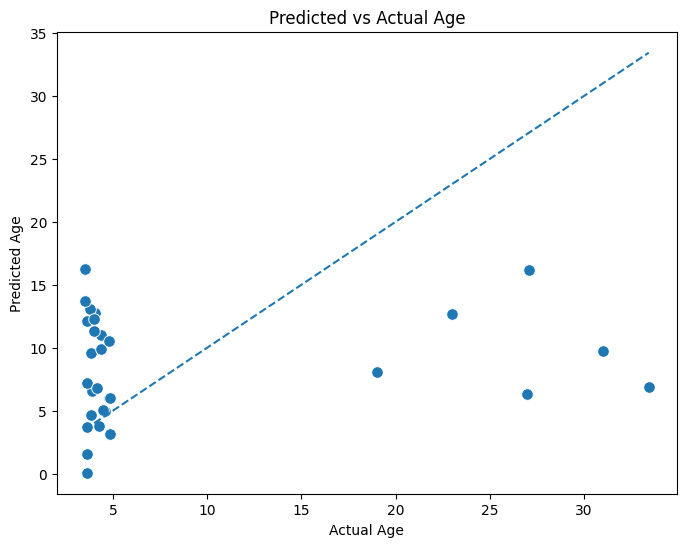

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=y_pred, s=70)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Actual Age")
plt.show()

In [9]:
model.fit(X, y)

coef = model.coef_
top_idx = np.argsort(np.abs(coef))[-10:]

print("Top predictive feature indices:")
print(top_idx)

Top predictive feature indices:
[700 333 617 202 214 780 852 754 159 337]
